# NAME: FARHANKHAN PATHAN
# ROLL NO.: 61
# CLASS: CSAI_D-3

9.Write a program to do following:

This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.

Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.
      Data Set: https://www.kaggle.com/shwetabh123/mall-customers

1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

Load Dataset

In [ ]:
df = pd.read_csv('Mall_Customers.csv')

print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Data Preprocessing

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

print("\nSelected Features:\n")
print(X.head())


Selected Features:

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Data Sample:\n", X_scaled[:5])


Scaled Data Sample:
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


Train-Test Split (For Formal Requirement)

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)


Training Data Size: (160, 2)
Testing Data Size: (40, 2)


K-Means Clustering

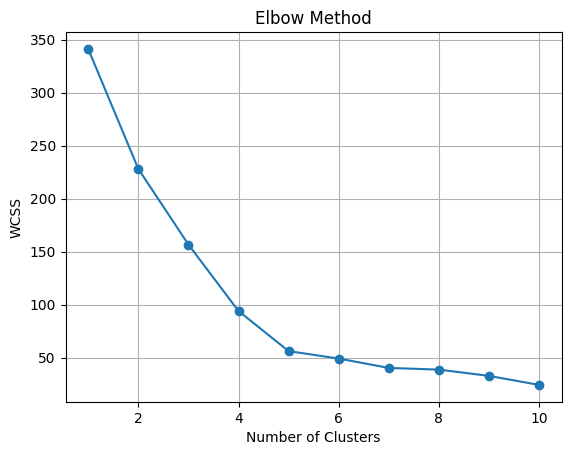

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_temp.fit(X_train)
    wcss.append(kmeans_temp.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

Text(0, 0.5, 'Spending Score (scaled)')

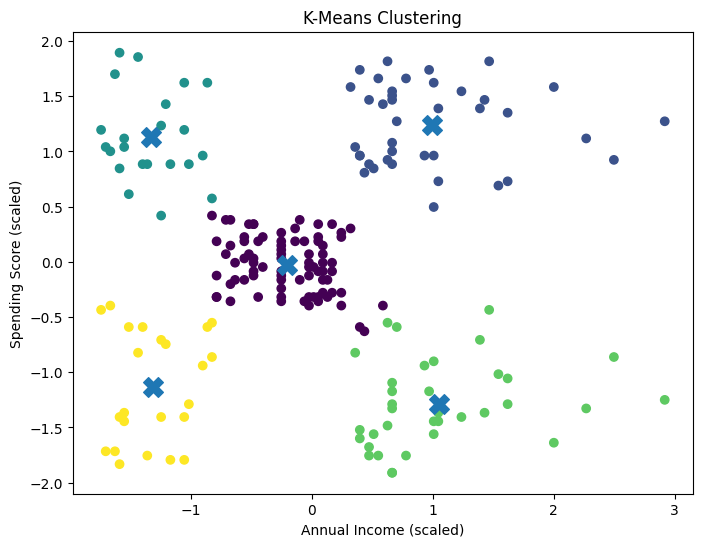

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')

Hierarchical Clustering

In [ ]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X_scaled)

Text(0, 0.5, 'Spending Score (scaled)')

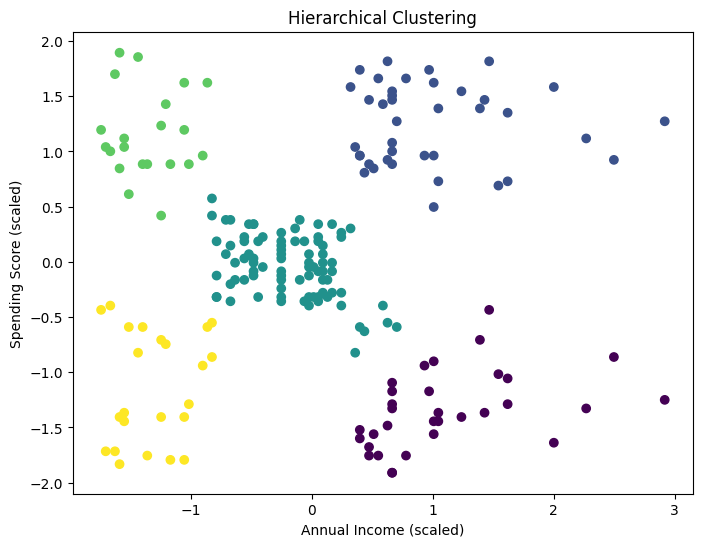

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_hc)
plt.title('Hierarchical Clustering')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')


Model Evaluation

In [ ]:
kmeans_score = silhouette_score(X_scaled, y_kmeans)
hc_score = silhouette_score(X_scaled, y_hc)

print("\nK-Means Silhouette Score:", round(kmeans_score, 3))
print("Hierarchical Silhouette Score:", round(hc_score, 3))


K-Means Silhouette Score: 0.555
Hierarchical Silhouette Score: 0.554
